save

In [14]:
# Standard Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings

# Scikit-Learn: Datasets
from ucimlrepo import fetch_ucirepo

# Scikit-Learn: Preprocessing, Imputation, & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Scikit-Learn: Model Selection, Evaluation, & Visualization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import NearestCentroid
from sklearn.neural_network import MLPClassifier


In [15]:
#SETUP/ PREPROCESSING

warnings.filterwarnings("ignore")

print("Fetching UCI Diabetes Dataset...")
diabetes = fetch_ucirepo(name='Diabetes 130-US Hospitals for Years 1999-2008') # previously df
X = diabetes.data.features
y = diabetes.data.targets['readmitted']

# Encode target (readmission).
# readmitted {0: '<30', 1: '>30', 2: 'NO'}
y = y.values.ravel()
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Handle missing data
X = X.replace('?', np.nan) # replace ? with NaN

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# preprocess data for use across all models
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])

print("Applying Preprocessing Pipeline...")
X_preprocessed = preprocessor.fit_transform(X)

Fetching UCI Diabetes Dataset...
Applying Preprocessing Pipeline...


In [19]:
# create data split based on project overview, section 4 experimental setup

seed = 1234
np.random.seed(seed)

# 60% Test Split
X_temp, X_te, y_temp, y_te = train_test_split(
    X_preprocessed, y_encoded, test_size=0.60, random_state=seed, stratify=y_encoded
)

# Split remaining 40% into 20% Train and 20% Validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp)

In [16]:
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [20]:
#y_encoded.head()

Linear Regression

Nearest Centroid

In [ ]:
# model = NearestCentroid(metric='euclidean')
# model.fit(X_tr, y_tr)
#
# y_acc_val = model.score(X_val, y_val)
# y_acc_te = model.score(X_te, y_te)

In [49]:
#the only noteworthy hyperparameter is how to calculate distance (metrics)
#metric{“euclidean”, “manhattan”}
#shrink_threshold turns nearest centroid into nearest shrunken centroid?
metrics = ["euclidean", "manhattan"]
shrink_thresholds = [None, 0.01, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5]
tuning_results = []
final_parameters = None

for metric, shrink_threshold in itertools.product(metrics, shrink_thresholds):
    parameters = {"metric":metric, "shrink_threshold":shrink_threshold}
    model = NearestCentroid(**parameters)
    model.fit(X_tr, y_tr)

    y_acc_tr = model.score(X_tr, y_tr)
    y_acc_val = model.score(X_val, y_val)

    if final_parameters is None or final_parameters[1] < y_acc_val:
        final_parameters = (parameters, y_acc_val)
    tuning_results.append({"params": parameters, "training accuracy":y_acc_tr,"validation accuracy":y_acc_val})

print(f"the best parameters are: {final_parameters}")
final_model = NearestCentroid(**final_parameters[0])
final_model.fit(X_tr, y_tr)
final_acc = final_model.score(X_te, y_te)

the best parameters are: ({'metric': 'manhattan', 'shrink_threshold': 1.5}, 0.5062152999557805)


In [50]:
tuning_table = pd.DataFrame(
    {**i["params"], "training accuracy": i["training accuracy"], "validation accuracy": i["validation accuracy"]} for i in tuning_results
)
print(tuning_table)

       metric  shrink_threshold  training accuracy  validation accuracy
0   euclidean               NaN           0.480814             0.474819
1   euclidean              0.01           0.480863             0.474721
2   euclidean              0.10           0.480666             0.474770
3   euclidean              0.30           0.480568             0.473984
4   euclidean              0.50           0.481600             0.474377
5   euclidean              0.70           0.482828             0.475262
6   euclidean              1.00           0.483565             0.475851
7   euclidean              1.50           0.483909             0.477325
8   manhattan               NaN           0.415713             0.412224
9   manhattan              0.01           0.415713             0.412224
10  manhattan              0.10           0.430944             0.429666
11  manhattan              0.30           0.454724             0.453840
12  manhattan              0.50           0.487545             0

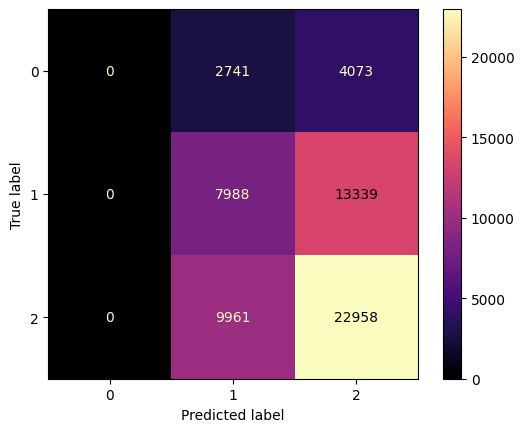

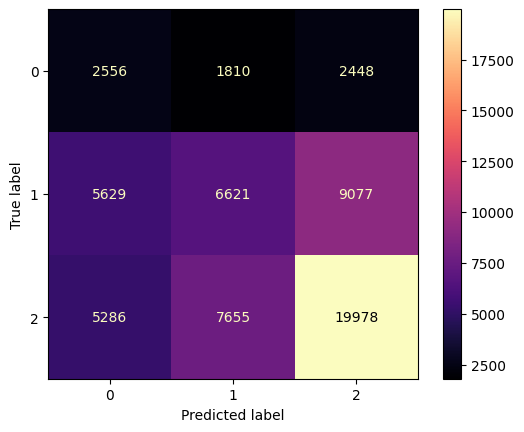

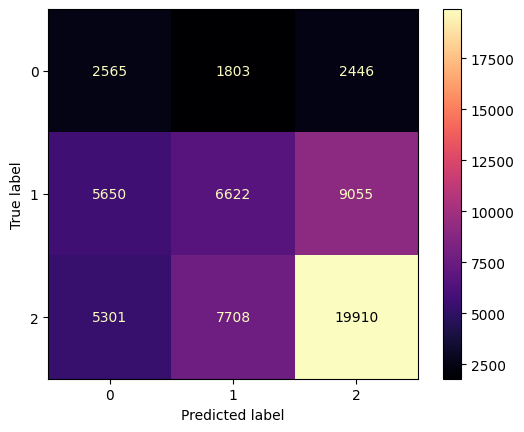

In [52]:
#although the accuracy is highest, the shrinking threshold (=0.5) doesnt predict y label 0
y_pred_te = final_model.predict(X_te)
c_matrix = confusion_matrix(y_te, y_pred_te)
confusion_model = ConfusionMatrixDisplay(confusion_matrix=c_matrix)
confusion_model.plot(cmap='magma', values_format='g')

#0.5
shrunk_model = NearestCentroid(**tuning_results[4]["params"])
shrunk_model.fit(X_tr, y_tr)
y_pred_te = shrunk_model.predict(X_te)
c_matrix = confusion_matrix(y_te, y_pred_te)
shrunk_confusion_model = ConfusionMatrixDisplay(confusion_matrix=c_matrix)
shrunk_confusion_model.plot(cmap='magma', values_format='g')

#no parameters
default_model = NearestCentroid()
default_model.fit(X_tr, y_tr)
y_pred_te = default_model.predict(X_te)
c_matrix = confusion_matrix(y_te, y_pred_te)
confusion_model = ConfusionMatrixDisplay(confusion_matrix=c_matrix)
confusion_model.plot(cmap='magma', values_format='g')

MLP

Logistic Classifiers